# Metalearners

- This notebook estimates heterogeneous treatment effects (CATE) with
  metalearners, and compares them on email marketing and discount data with
  gain curves
- The pedagogical arc:
  - Loading a biased (observational) and a randomized email marketing
    dataset
  - T-Learner: separate outcome models per treatment arm
  - X-Learner: second-stage models with propensity-score weighting
  - S-Learner: a single model with treatment as a covariate, and
    counterfactual predictions
  - Double ML / R-Learner: debiasing and denoising nuisance models

In [3]:
# `lightgbm`/`fklearn` are extras for this notebook, not in the shared
# requirements.txt, so they are self-installed here (see `utils` for the
# `fklearn` usage).
import helpers.hmodule as hmodule

hmodule.install_module_if_not_present(
    ["lightgbm", "fklearn"],
    use_activate=True,
    use_sudo=False,
    venv_path="/opt/venv",
)

Module 'lightgbm' is already installed.
Module 'fklearn' is already installed.


In [ ]:
%load_ext autoreload
%autoreload 2

import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from lightgbm import LGBMRegressor

In [2]:
import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook

import L08_04_07_metalearners_utils as utils

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
_LOG = logging.getLogger(__name__)
utils.init_loggers(_LOG)

# Convert `display` into `print()` when running outside IPython.
try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

pymc is not installed
arviz is not installed
preliz is not installed
sns is not installed


Python 3.12.13
Linux 3a71c0a7bf16 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 GNU/Linux


# Part 1: Loading Data

## Cell 1.1: Loading the email marketing datasets

**Goal**
- Load a biased (observational) and a randomized email marketing
  dataset, sharing the same schema, used throughout the T/X-Learner
  sections

In [4]:
dir_name = "L08_data"
!ls $dir_name

out_dir_name = "figures/"

In [5]:
data_biased = pd.read_csv(f"{dir_name}/email_obs_data.csv")
print("# data_biased")
print("num_rows=", len(data_biased))
display(data_biased.head())

data_rnd = pd.read_csv(f"{dir_name}/email_rnd_data.csv")
print("# data_rnd")
print("num_rows=", len(data_rnd))
display(data_rnd.head())

# data_biased
num_rows= 300000


,mkt_email,next_mnth_pv,age,tenure,ammount_spent,vehicle,food,beverage,art,baby,...,electronics,sports,tools,games,industry,pc,jewel,books,music_books_movies,health
0,0,34.38,32.0,0.0,18.05,0,0,1,1,1,...,3,0,1,0,1,2,2,0,1,1
1,0,183.14,23.0,1.0,182.97,0,0,0,1,0,...,1,1,0,0,0,2,2,1,2,1
2,0,54.26,29.0,0.0,29.57,0,0,0,1,4,...,3,0,0,0,3,0,0,0,1,4
3,1,1409.71,44.0,0.0,142.15,1,2,0,1,0,...,1,0,1,1,1,3,0,1,0,5
4,0,120.16,30.0,0.0,132.11,0,1,1,0,1,...,1,2,1,1,2,3,0,0,2,5


# data_rnd
num_rows= 10000


,mkt_email,next_mnth_pv,age,tenure,ammount_spent,vehicle,food,beverage,art,baby,...,electronics,sports,tools,games,industry,pc,jewel,books,music_books_movies,health
0,0,244.26,61.0,1.0,21.84,0,2,2,0,2,...,1,0,0,3,1,0,1,0,0,2
1,0,29.67,36.0,1.0,107.40,0,2,0,2,0,...,1,1,1,2,1,2,1,0,2,2
2,0,11.73,64.0,0.0,59.81,0,1,0,0,0,...,2,0,0,3,0,1,0,1,0,1
3,0,41.41,74.0,0.0,62.98,0,1,0,0,3,...,1,0,2,2,1,1,0,4,1,0
4,0,447.89,59.0,0.0,72.56,0,1,1,3,2,...,5,0,0,1,0,0,1,1,2,1


In [6]:
hdbg.dassert_eq(data_biased.columns.tolist(), data_rnd.columns.tolist())

In [7]:
y = "next_mnth_pv"
T = "mkt_email"
X = list(data_rnd.drop(columns=[y, T]).columns)

train, test = data_biased, data_rnd

display(train[[T, y]].head())

# Part 2: T-Learner

## Cell 2.1: Fitting separate outcome models per treatment arm

**Goal**
- Fit one outcome model on the control arm and one on the treated arm,
  the T-Learner's defining idea, then predict the CATE as their
  difference

**Implementation**
- `m0`/`m1` are `LGBMRegressor` models fit on `T==0`/`T==1` rows
  respectively; `cate = m1.predict(x) - m0.predict(x)`

In [8]:
np.random.seed(123)

m0 = LGBMRegressor()
m1 = LGBMRegressor()

m0.fit(train.query(f"{T}==0")[X].values, train.query(f"{T}==0")[y].values)
_ = m1.fit(train.query(f"{T}==1")[X].values, train.query(f"{T}==1")[y].values)

display(m0)

,mkt_email,next_mnth_pv
0,0,34.38
1,0,183.14
2,0,54.26
3,1,1409.71
4,0,120.16


## Cell 2.2: Evaluating the T-Learner CATE with a gain curve

**Goal**
- Check the T-Learner's CATE estimate on the held-out randomized data,
  via a cumulative gain curve

**Implementation** `utils.plot_gain_curve_analysis(cate_test, T, y, ...)`

In [9]:
t_learner_cate_test = test.assign(
    cate=m1.predict(test[X].values) - m0.predict(test[X].values)
)

_ = utils.plot_gain_curve_analysis(t_learner_cate_test, T, y, title="T-Learner")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 146759, number of used features: 25
[LightGBM] [Info] Start training from score 88.249324
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 550
[LightGBM] [Info] Number of data points in the train set: 153241, number of used features: 25
[LightGBM] [Info] Start training from score 1596.224063


## Cell 2.3: Visualizing treatment-effect heterogeneity on synthetic data

**Goal**
- Fit the same T-Learner pattern on synthetic data with a known,
  heterogeneous treatment effect, to visualize what the 2 outcome
  models and the resulting CATE actually look like

**Implementation** `utils.generate_synthetic_treatment_data(...)`,
`utils.fit_tlearner_models(...)`,
`utils.plot_tlearner_treatment_effect_analysis(...)`

In [10]:
# Generate synthetic data with treatment heterogeneity.
df = utils.generate_synthetic_treatment_data(n0=500, n1=50, seed=123)

# Fit separate outcome models for control and treatment groups.
m0, m1, m0_hat, m1_hat = utils.fit_tlearner_models(df, min_child_samples=25)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


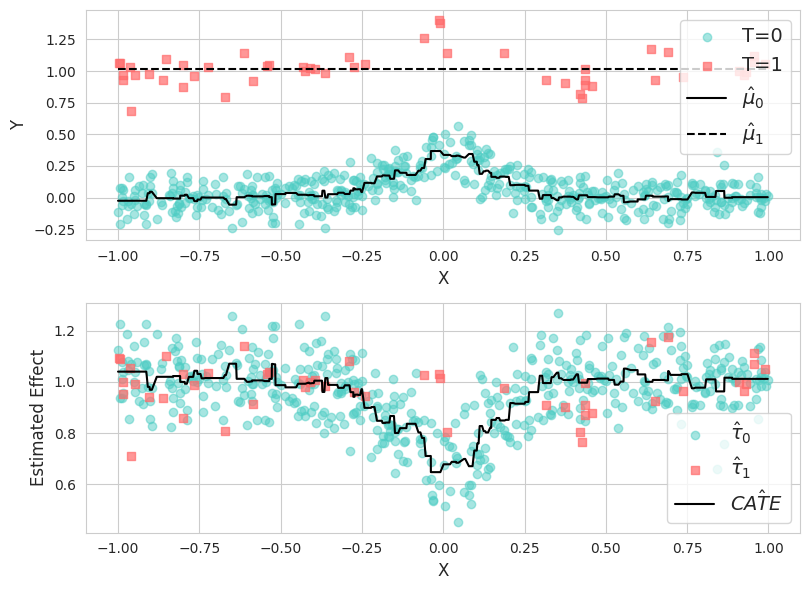

In [13]:
# Visualize outcome models and heterogeneous treatment effects.
utils.plot_tlearner_treatment_effect_analysis(df, m0, m1, m0_hat, m1_hat)

# Part 3: X-Learner

## Cell 3.1: Estimating heterogeneous treatment effects

**Goal**
- Compute the X-Learner's imputed treatment effects: for each unit, the
  difference between its observed outcome and the *other* arm's
  predicted outcome

**Implementation**
- `utils.calculate_xlearner_heterogeneous_treatment_effects(df, m0, m1)`

In [ ]:
tau_0, tau_1 = utils.calculate_xlearner_heterogeneous_treatment_effects(
    df, m0, m1
)

## Cell 3.2: Fitting X-Learner second-stage models on synthetic data

**Goal**
- Fit a second-stage model on each arm's imputed effects, then compare
  the resulting CATE estimates against the ground truth

**Implementation** `utils.fit_xlearner_models(df, tau_0, tau_1, ...)`,
`utils.plot_xlearner_effect_estimates(...)`

In [ ]:
mu_tau0, mu_tau1, mu_tau0_hat, mu_tau1_hat = utils.fit_xlearner_models(
    df, tau_0, tau_1, min_child_samples=25
)

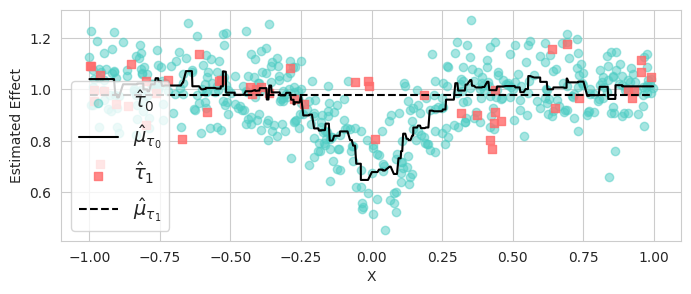

In [14]:
# Plot heterogeneous treatment effect estimates.
utils.plot_xlearner_effect_estimates(df, tau_0, tau_1, mu_tau0_hat, mu_tau1_hat)

## Cell 3.3: Visualizing propensity-score-weighted CATE

**Goal**
- Combine the 2 second-stage estimates into a single CATE, weighted by
  the propensity score, and visualize the result

**Implementation** `utils.plot_xlearner_with_propensity_scores(...)`

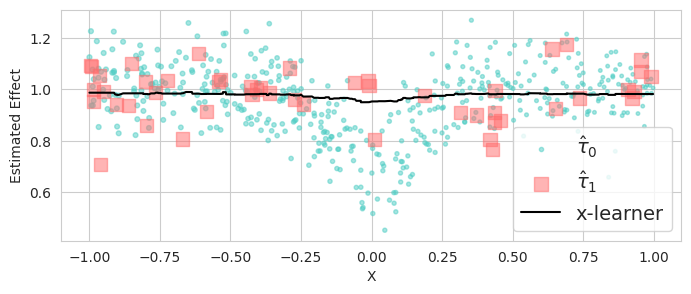

In [15]:
utils.plot_xlearner_with_propensity_scores(df, mu_tau0, mu_tau1, tau_0, tau_1)

## Cell 3.4: Fitting the propensity-score-weighted X-Learner on real data

**Goal**
- Repeat the X-Learner pattern on the real email data: first-stage
  models weighted by the inverse propensity score, then second-stage
  models on the residual treatment effects

**Implementation**
- `utils.fit_propensity_score_and_weighted_outcome_models(train, X, T, y)`
- `utils.fit_xlearner_second_stage_models(train, X, T, y, m0, m1)`

In [16]:
# Fit propensity score model and first-stage outcome models with inverse
# probability weighting.
ps_model, m0, m1 = utils.fit_propensity_score_and_weighted_outcome_models(
    train, X, T, y
)

In [17]:
# Fit second-stage models on residual treatment effects.
m_tau_0, m_tau_1 = utils.fit_xlearner_second_stage_models(train, X, T, y, m0, m1)

## Cell 3.5: Evaluating the X-Learner CATE with a gain curve

**Goal**
- Check the X-Learner's CATE estimate on the held-out data, via the
  same cumulative gain curve used for the T-Learner

In [18]:
x_cate_test = utils.estimate_xlearner_cate(test, X, ps_model, m_tau_0, m_tau_1)

_ = utils.plot_gain_curve_analysis(x_cate_test, T, y, title="X-Learner")

# Part 4: S-Learner

## Cell 4.1: Loading the discount dataset

**Goal**
- Load a continuous-treatment dataset (discount level, not a binary
  flag), split chronologically into train/test

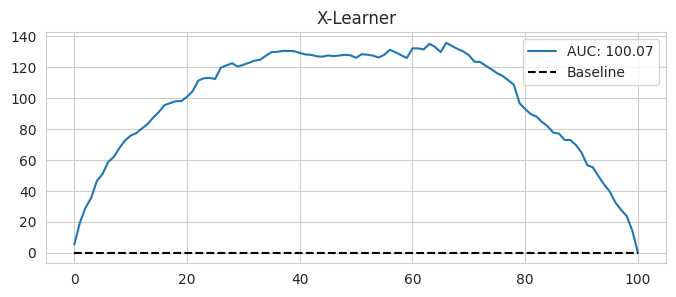

In [19]:
data_cont = pd.read_csv(f"{dir_name}/discount_data.csv")
print("data_cont.shape[0]=", data_cont.shape[0])
display(data_cont.head())

In [ ]:
train = data_cont.query("day<'2018-01-01'")
print("train.shape[0]=", train.shape[0])
test = data_cont.query("day>='2018-01-01'")
print("test.shape[0]=", test.shape[0])

## Cell 4.2: Fitting a single shared-covariate model

**Goal**
- Fit one model with treatment as a plain input feature (the S-Learner
  pattern), instead of 2 separate per-arm models

**Implementation** `utils.fit_slearner_model(train, X, T, y)`

In [22]:
X = ["month", "weekday", "is_holiday", "competitors_price"]
T = "discounts"
y = "sales"

s_learner = utils.fit_slearner_model(train, X, T, y)

## Cell 4.3: Generating counterfactual predictions

**Goal**
- Sweep the discount level through a grid of counterfactual values, to
  see how predicted sales respond

**Implementation**
- `utils.generate_slearner_counterfactual_predictions(test, X, T, y,
  s_learner, discount_grid)`

In [23]:
test_cf = utils.generate_slearner_counterfactual_predictions(
    test, X, T, y, s_learner, np.array([0, 10, 20, 30, 40])
)

display(test_cf.head(8))

,rest_id,day,month,weekday,weekend,is_holiday,is_dec,is_nov,competitors_price,sales,key,discounts,sales_hat
0,0,2018-01-01,1,0,False,True,False,False,4.92,251.5,1,0,67.957972
1,0,2018-01-01,1,0,False,True,False,False,4.92,251.5,1,10,444.245941
2,0,2018-01-01,1,0,False,True,False,False,4.92,251.5,1,20,793.045769
3,0,2018-01-01,1,0,False,True,False,False,4.92,251.5,1,30,1279.640793
4,0,2018-01-01,1,0,False,True,False,False,4.92,251.5,1,40,1512.630767
5,0,2018-01-02,1,1,False,False,False,False,3.06,541.0,1,0,65.672080
6,0,2018-01-02,1,1,False,False,False,False,3.06,541.0,1,10,495.669220
7,0,2018-01-02,1,1,False,False,False,False,3.06,541.0,1,20,1015.401471


## Cell 4.4: Visualizing counterfactual sales curves

**Goal**
- Plot the predicted sales-vs-discount curve for a few selected days,
  for one restaurant, to see how the shape varies day to day

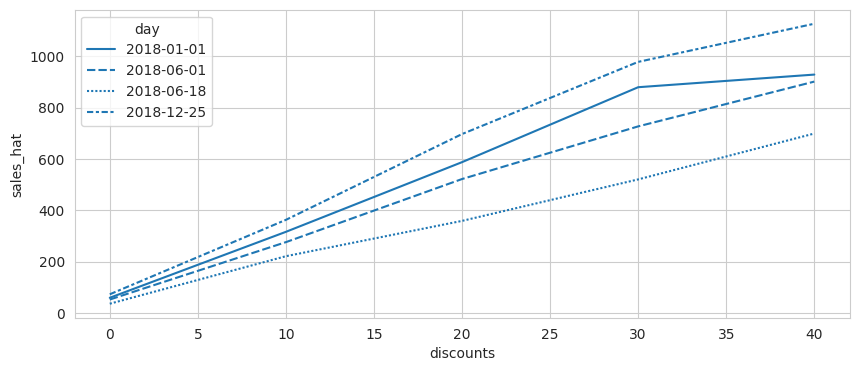

In [24]:
days = ["2018-12-25", "2018-01-01", "2018-06-01", "2018-06-18"]

plt.figure(figsize=(10, 4))
_ = sns.lineplot(
    data=test_cf.query("day.isin(@days)").query("rest_id==2"),
    y="sales_hat",
    x="discounts",
    style="day",
)

## Cell 4.5: Evaluating the S-Learner CATE with a gain curve

**Goal**
- Estimate the CATE from the counterfactual predictions, then check it
  with the same cumulative gain curve used for the T/X-Learners

**Implementation** `utils.estimate_slearner_cate(test_cf, test, T, y)`

In [25]:
test_s_learner_pred = utils.estimate_slearner_cate(test_cf, test, T, y)

display(test_s_learner_pred.head())

,competitors_price,day,is_dec,is_holiday,is_nov,month,rest_id,sales,weekday,weekend,discounts,cate
0,4.92,2018-01-01,False,True,False,1,0,251.5,0,False,5,37.247404
1,3.06,2018-01-02,False,False,False,1,0,541.0,1,False,10,40.269854
2,4.61,2018-01-03,False,False,False,1,0,431.0,2,False,10,37.412988
3,4.84,2018-01-04,False,False,False,1,0,760.0,3,False,20,38.436815
4,6.29,2018-01-05,False,False,False,1,0,78.0,4,False,0,31.428603


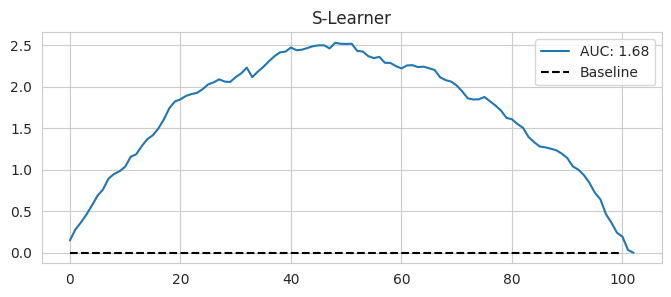

In [26]:
_ = utils.plot_gain_curve_analysis(test_s_learner_pred, T, y, title="S-Learner")

# Part 5: Double ML / R-Learner

## Cell 5.1: Fitting the debiasing and denoising nuisance models

**Goal**
- Fit the 2 nuisance models the R-Learner needs: one predicting
  treatment from covariates (debiasing), one predicting outcome from
  covariates alone (denoising)

**Implementation** `utils.fit_rlearner_models(train, X, T, y)`

In [27]:
X = ["month", "weekday", "is_holiday", "competitors_price"]
T = "discounts"
y = "sales"

# Fit debiasing and denoising models.
debias_m, denoise_m = utils.fit_rlearner_models(train, X, T, y)

## Cell 5.2: Fitting the R-Learner CATE model on residuals

**Goal**
- Regress the outcome residual on the treatment residual (both from the
  nuisance models above), whose slope is the R-Learner's CATE estimate

**Implementation** `utils.fit_rlearner_cate_model(train, X, T, y,
debias_m, denoise_m)`

In [28]:
cate_model, t_res, y_res = utils.fit_rlearner_cate_model(
    train, X, T, y, debias_m, denoise_m
)

## Cell 5.3: Checking coefficients via an OLS diagnostic

**Goal**
- Cross-check the R-Learner's residual-on-residual regression against a
  plain OLS fit, as an optional diagnostic

In [29]:
display(sm.OLS(y_res, t_res).fit().summary().tables[1])

,coef,std err,t,P>|t|,[0.025,0.975]
discounts,31.4634,0.151,209.017,0.000,31.168,31.759


## Cell 5.4: Evaluating the R-Learner CATE with a gain curve

**Goal**
- Estimate the CATE on the test set, then check it with the same
  cumulative gain curve used for the other 3 metalearners

In [30]:
test_r_learner_pred = utils.estimate_rlearner_cate(test, X, cate_model)

_ = utils.plot_gain_curve_analysis(test_r_learner_pred, T, y, title="R-Learner")